In [6]:
class LikertSurvey:
    def __init__(self):
        self.csv_path = "USSF Likert Survey Questions.csv"
        self.questions = self._load_questions()
        self.responses = self._load_responses()
    
    def _load_questions(self):
        import pandas as pd
        df = pd.read_csv(self.csv_path)
        return df['Statement'].tolist()

    def get_questions(self):
        return self.questions



In [9]:
import ollama
# split the questions into a list of strings by the newline character
questions_list = questions.split('\n')

# print the list of questions
print(len(questions_list))

embeddings_list = []
for line in questions_list:
    # embed the text using ollama local embedding model
    embedding = ollama.embed(input=line, model="nomic-embed-text")
    # if this is the first line, create the list, otherwise append to it
    embeddings_list.append(embedding['embeddings'][0])

print(len(embeddings_list))





100
100


In [10]:
print(embeddings_list[0])

[-0.012092152, 0.0145348245, -0.18653873, 0.030862615, 0.03483902, 0.0074342317, 0.054988742, 0.021292288, 0.039367814, -0.025521355, -0.013848931, -0.0061483616, 0.077401765, 0.035813283, 0.036798418, -0.00918206, 0.01825025, -0.06340254, -0.02771154, -0.077560544, 0.02754467, 0.007171405, 0.051063865, -0.01980814, 0.06807968, 0.064927526, -0.016199097, -0.046154365, -0.0373964, 0.022986704, 0.058256112, 0.019708999, -0.0035990842, -0.02359312, 0.023408335, -0.07333493, -0.040731482, 0.02192973, -0.0050806645, -0.029058937, -0.0048786853, -0.024234232, 0.0055856095, -0.06104064, 0.02321324, -0.041448448, 0.034353, -0.016201193, 0.063872844, -0.021450838, -0.04008755, -0.014722583, -0.0160011, 0.047239166, -0.017923709, -0.058807045, 0.0037132292, 0.006886851, -0.051766027, -0.001964329, 0.07439042, 0.02511708, -0.041876044, 0.04467168, 0.00064542465, 0.05341326, -0.046884634, 0.026091767, -0.055429213, -0.044957913, -0.0043100337, 0.007391684, 0.023872953, 0.030953763, -0.061067943, 0

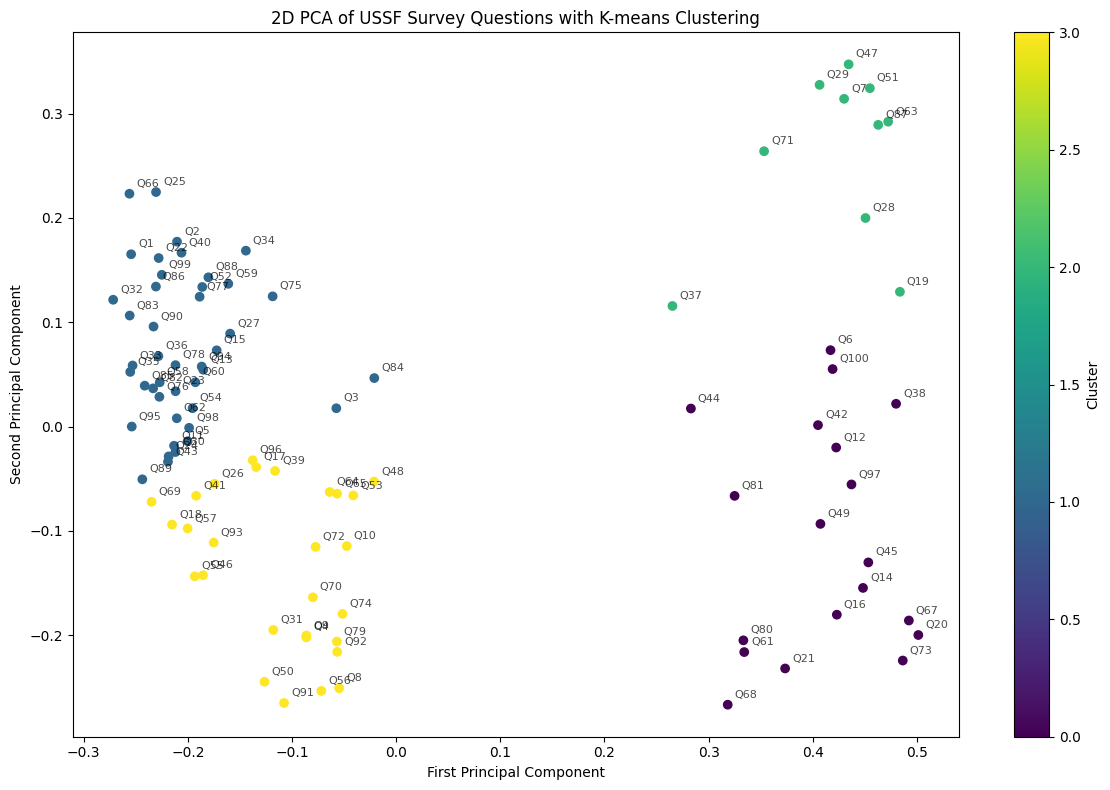

Explained variance ratio: [0.19699369 0.06064104]


In [11]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Convert embeddings list to numpy array
embeddings_array = np.array(embeddings_list)

# Create and fit PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_array)

# Perform K-means clustering
n_clusters = 4  # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(embeddings_2d)

# Create scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=clusters, cmap='viridis')
plt.title('2D PCA of USSF Survey Questions with K-means Clustering')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add legend
plt.colorbar(scatter, label='Cluster')

# Add text labels for each point
for i, txt in enumerate(questions_list):
    plt.annotate(f'Q{i+1}', (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Print explained variance ratio
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
